# Progetto di Linguistica Computazionale II - Matilde Viti
# Task 3: Classificatore basato su SVM lineari e word embedding

In [207]:
import numpy as np
import re
import os
import copy
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


from support_task2 import load_json, split_dataset
from support_task3 import load_word_embeddings, build_document_embedding

In [208]:
class Document:
    def __init__(self, document_path, user_info_dict):
        self.document_path = document_path
        self.doc_id = None
        self.split = None
        self._load_doc_info(document_path, user_info_dict)
        self.sentences = []
        self.features = None
        
    def _load_doc_info(self, document_path, user_info_dict):
        self.doc_id = os.path.splitext(os.path.basename(document_path))[0]
        self.split = user_info_dict[self.doc_id]['split']
        self.author = user_info_dict[self.doc_id]['author']
    
    def __str__(self):
        return ' '.join([token.word for token in self.tokens])


class Token:
    def __init__(self, word, pos):
        self.word = word
        self.pos = pos

    def __str__(self):
        return f'Word = {self.word}, POS = {self.pos}'

In [209]:
embeddings_dim = 128
embeddings_path = f"ukwac{embeddings_dim}.txt" # percorso del file di embeddings

In [210]:
emb_dict = load_word_embeddings(embeddings_path) # carico gli embeddings in memoria

In [211]:
conllu_dir = "./file_conllu" # percorso della cartella contenente i file .conllu
user_info_dict_path = "paragraph_info.json" 

# Uso la funzione di support_task2 per caricare il dizionario
user_info_dict = load_json(user_info_dict_path)


# Normalizzazione delle parole

In [212]:
def get_digits(text): 
    try:
      val = int(text)
    except:
      text = re.sub(r'\d', '@Dg', text)
      return text
    if val >= 0 and val < 2100:
      return str(val)
    else:
      return "DIGLEN_" + str(len(str(val)))

def normalize_text(word):
    if "http" in word or ("." in word and "/" in word):
      word = str("___URL___")
      return word
    if len(word) > 26:
      return "__LONG-LONG__"
    new_word = get_digits(word)
    if new_word != word:
      word = new_word
    if word[0].isupper():
      word = word.capitalize()
    else:
      word = word.lower()
    return word

### Estrazione dei token da file CoNLL-U

In [248]:
def get_tokens_from_file(src_path):
    document_tokens = []
    lines_to_skip = 0
    take_pos = False
    for line in open(src_path, 'r'):
        if line[0].isdigit():
            splitted_line = line.strip().split('\t')
            if '-' in splitted_line[0]:
                skip_ids = splitted_line[0].split('-')
                lines_to_skip = int(skip_ids[1]) - int(skip_ids[0]) + 1 # l'indice ci indica quali righe saltare
                take_pos = True # booleano che indica che dobbiamo prendere la pos della prossima parola
                word = normalize_text(splitted_line[1]) # normalizziamo la parola
                pos = splitted_line[3]
                token = Token(word=word, pos=None) # inizializziamo il token con la forma, il pos lo prendiamo nella riga successiva
                document_tokens.append(token)
            else:
                if lines_to_skip == 0:   
                    word = normalize_text(splitted_line[1])
                    pos = splitted_line[3]
                    token = Token(word=word, pos=pos)
                    document_tokens.append(token)
                if take_pos:
                    pos = splitted_line[3]
                    document_tokens[-1].pos = pos
                    take_pos = False
                lines_to_skip = max(0, lines_to_skip-1)
    return document_tokens

In [214]:
all_documents = []

for file_name in os.listdir(conllu_dir):
    file_path = os.path.join(conllu_dir, file_name)

    if '.ipynb_checkpoints' not in file_path:
        document = Document(file_path, user_info_dict)
        document_tokens = get_tokens_from_file(file_path)
        document.tokens = document_tokens
        all_documents.append(document)

# Estrazione features

In [215]:
features_by_setting = {}

def extract_features(documents, pos_list, method, setting_name):
    """
    Estrae le feature da una lista di documenti aggregando i word embeddings
    secondo un metodo specificato

    Args:
        documents (list): lista di oggetti Document con attributo `tokens`
        pos_list (list of str): POS da considerare
        method (str): metodo di aggregazione ('mean', 'sum', 'max')
        setting_name (str): nome della configurazione sperimentale
    """

    docs_copy = copy.deepcopy(documents)

    for doc in docs_copy:
        doc_embedding = build_document_embedding(
            doc.tokens,
            emb_dict,
            embeddings_dim,
            pos_list,
            method
        )

        doc.features = doc_embedding

    features_by_setting[setting_name] = docs_copy

# Configurazione con metodo di aggregazione **mean**

- 1: POS considerati: NOUN, VERB, ADJ (accuracy 0.73, macro F1 0.73)
- 1a: POS considerati: VERB, NOUN, INTJ, DET (accuracy 0.71, macro F1 0.71)


1) Prima configurazione (mean)

In [216]:
extract_features(all_documents, ["NOUN", "ADJ", "VERB"], "mean", "config_1")

In [217]:
train_features_1, train_labels_1, val_features_1, val_labels_1, test_features_1, test_labels_1 = split_dataset(features_by_setting["config_1"])

In [218]:
X_train_1 = np.array(train_features_1)
y_train_1 = np.array(train_labels_1)
X_val_1 = np.array(val_features_1)
y_val_1 = np.array(val_labels_1)

In [219]:
pipeline_1 = Pipeline([
    ("scaler", StandardScaler()), 
    ("svc", LinearSVC(
        C=1.0,
        class_weight=None,
        dual=False,
        max_iter=10000,
        random_state=42
    ))
])


# 3. Addestramento del modello
pipeline_1.fit(X_train_1, y_train_1)

# 4. Valutazione
a1_y_pred = pipeline_1.predict(X_val_1)

print(classification_report(y_val_1, a1_y_pred))

                  precision    recall  f1-score   support

Charlotte Bronte       0.70      0.73      0.72       200
    George Eliot       0.67      0.77      0.71       200
     Jane Austen       0.86      0.69      0.76       200

        accuracy                           0.73       600
       macro avg       0.74      0.73      0.73       600
    weighted avg       0.74      0.73      0.73       600



1a) Seconda configurazione (mean):



In [220]:
extract_features(all_documents, ["INTJ", "NOUN", "VERB", "DET"], "mean", "config_1a")

In [221]:
train_features_1a, train_labels_1a, val_features_1a, val_labels_1a, test_features_1a, test_labels_1a = split_dataset(features_by_setting["config_1a"])

In [222]:
X_train_1a = np.array(train_features_1a)
y_train_1a = np.array(train_labels_1a)
X_val_1a = np.array(val_features_1a)
y_val_1a = np.array(val_labels_1a)

In [223]:
pipeline_1a = Pipeline([
    ("scaler", StandardScaler()), 
    ("svc", LinearSVC(
        C=1.0,
        class_weight=None,  
        dual=False,
        max_iter=10000,
        random_state=42
    ))
])


# 3. Addestramento del modello
pipeline_1a.fit(X_train_1a, y_train_1a)

# 4. Valutazione
a1a_y_pred = pipeline_1a.predict(X_val_1a)

print(classification_report(y_val_1a, a1a_y_pred))

                  precision    recall  f1-score   support

Charlotte Bronte       0.67      0.70      0.69       200
    George Eliot       0.67      0.78      0.72       200
     Jane Austen       0.82      0.66      0.73       200

        accuracy                           0.71       600
       macro avg       0.72      0.71      0.71       600
    weighted avg       0.72      0.71      0.71       600



# Configurazione con metodo di aggregazione **SUM**
2. POS considerati: NOUN, ADJ, VERB (accuracy: 0.73, macro f1: 0.73)  
2a. POS considerati: VERB, NOUN, INTJ, DET (accuracy: 0.71, macro f1: 0.71)



2) Prima configurazione (sum)


In [224]:
extract_features(all_documents, ["NOUN", "ADJ", "VERB"], "sum", "conf_2")

In [225]:
train_features_2, train_labels_2, val_features_2, val_labels_2, test_features_2, test_labels_2 = split_dataset(features_by_setting["conf_2"])

In [226]:
X_train_2 = np.array(train_features_2)
y_train_2 = np.array(train_labels_2)
X_val_2 = np.array(val_features_2)
y_val_2 = np.array(val_labels_2)

In [227]:
pipeline_2 = Pipeline([
    ("scaler", StandardScaler()), 
    ("svc", LinearSVC(
        C=1.0,
        class_weight=None,  
        dual=False,
        max_iter=10000,
        random_state=42
    ))
])


# 3. Addestramento del modello
pipeline_2.fit(X_train_2, y_train_2)

# 4. Valutazione
a2_y_pred = pipeline_2.predict(X_val_2)

print(classification_report(y_val_2, a2_y_pred, zero_division=0))

                  precision    recall  f1-score   support

Charlotte Bronte       0.71      0.72      0.72       200
    George Eliot       0.66      0.78      0.71       200
     Jane Austen       0.85      0.68      0.76       200

        accuracy                           0.73       600
       macro avg       0.74      0.73      0.73       600
    weighted avg       0.74      0.73      0.73       600



2a) Seconda configurazione (sum)

In [228]:
extract_features(all_documents,["VERB", "NOUN", "INTJ", "DET"], "sum", "conf_2a")

In [229]:
train_features_2a, train_labels_2a, val_features_2a, val_labels_2a, test_features_2a, test_labels_2a = split_dataset(features_by_setting["conf_2a"])

In [230]:
X_train_2a = np.array(train_features_2a)
y_train_2a = np.array(train_labels_2a)
X_val_2a = np.array(val_features_2a)
y_val_2a = np.array(val_labels_2a)

In [231]:
pipeline_2a = Pipeline([
    ("scaler", StandardScaler()), 
    ("svc", LinearSVC(
        C=1.0,
        class_weight=None,  
        dual=False,
        max_iter=10000,
        random_state=42
    ))
])


# 3. Addestramento del modello
pipeline_2a.fit(X_train_2a, y_train_2a)

# 4. Valutazione
a2a_y_pred = pipeline_2a.predict(X_val_2a)

print(classification_report(y_val_2a, a2a_y_pred, zero_division=0))

                  precision    recall  f1-score   support

Charlotte Bronte       0.69      0.69      0.69       200
    George Eliot       0.66      0.78      0.72       200
     Jane Austen       0.81      0.66      0.72       200

        accuracy                           0.71       600
       macro avg       0.72      0.71      0.71       600
    weighted avg       0.72      0.71      0.71       600



# Configurazione con metodo di aggregazione _max_


- 3: POS considerati: NOUN, ADJ, VERB (accuracy: 0.62, macro f1: 0.62)
- 3a: POS considerati: DET, PRON, AUX, ADP (accuracy: 0.62, macro f1: 0.62)


3) Prima configurazione (max)

In [232]:
extract_features(all_documents, ["NOUN", "ADJ", "VERB"], "max", "conf_3")

In [233]:
train_features_3, train_labels_3, val_features_3, val_labels_3, test_features_3, test_labels_3 = split_dataset(features_by_setting["conf_3"])

In [234]:
X_train_3 = np.array(train_features_3)
y_train_3 = np.array(train_labels_3)
X_val_3 = np.array(val_features_3)
y_val_3 = np.array(val_labels_3)

In [235]:
pipeline_3 = Pipeline([
    ("scaler", StandardScaler()), 
    ("svc", LinearSVC(
        C=1.0,
        class_weight=None,  
        dual=False,
        max_iter=10000,
        random_state=42
    ))
])


# 3. Addestramento del modello
pipeline_3.fit(X_train_3, y_train_3)

# 4. Valutazione
a3_y_pred = pipeline_3.predict(X_val_3)

print(classification_report(y_val_3, a3_y_pred, zero_division=0))

                  precision    recall  f1-score   support

Charlotte Bronte       0.60      0.61      0.61       200
    George Eliot       0.58      0.71      0.64       200
     Jane Austen       0.73      0.55      0.63       200

        accuracy                           0.62       600
       macro avg       0.64      0.62      0.62       600
    weighted avg       0.64      0.62      0.62       600



3a) Seconda configurazione (max)  


In [236]:
extract_features(all_documents, ["VERB", "NOUN", "INTJ", "DET"], "max", "conf_3a")

In [237]:
train_features_3a, train_labels_3a, val_features_3a, val_labels_3a, test_features_3a, test_labels_3a = split_dataset(features_by_setting["conf_3a"])

In [238]:
X_train_3a = np.array(train_features_3a)
y_train_3a = np.array(train_labels_3a)
X_val_3a = np.array(val_features_3a)
y_val_3a = np.array(val_labels_3a)

In [239]:
pipeline_3a = Pipeline([
    ("scaler", StandardScaler()), 
    ("svc", LinearSVC(
        C=1.0,
        class_weight=None,  
        dual=False,
        max_iter=10000,
        random_state=42
    ))
])


# 3. Addestramento del modello
pipeline_3a.fit(X_train_3a, y_train_3a)

# 4. Valutazione
a3a_y_pred = pipeline_3a.predict(X_val_3a)

print(classification_report(y_val_3a, a3a_y_pred, zero_division=0))

                  precision    recall  f1-score   support

Charlotte Bronte       0.60      0.60      0.60       200
    George Eliot       0.56      0.71      0.63       200
     Jane Austen       0.74      0.54      0.62       200

        accuracy                           0.62       600
       macro avg       0.63      0.62      0.62       600
    weighted avg       0.63      0.62      0.62       600



# Applicazione e valutazione della configurazione vincente su test set 

Le configurazioni con performance migliore sul validation set sono (a pari merito):   
a) MEAN: NOUN, VERB, ADJ (accuracy 0.73, macro F1 0.73)  
b) SUM: NOUN, VERB, ADJ (accuracy 0.73, macro F1 0.73)

a) MEAN

In [244]:
# Predizione sul test set di prima configurazione mean su NOUN, ADJ, VERB
test_pred_1 = pipeline_1.predict(test_features_1)   

print(classification_report(test_labels_1, test_pred_1, zero_division=0))

                  precision    recall  f1-score   support

Charlotte Bronte       0.60      0.56      0.58       194
    George Eliot       0.55      0.72      0.63       200
     Jane Austen       0.70      0.52      0.59       200

        accuracy                           0.60       594
       macro avg       0.61      0.60      0.60       594
    weighted avg       0.61      0.60      0.60       594



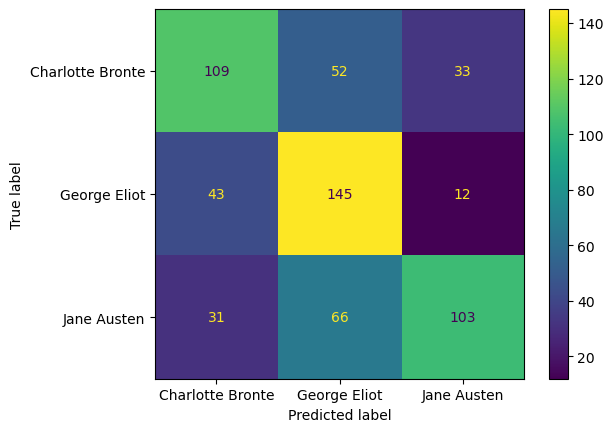

In [245]:
# Confusion matrix per la configurazione MEAN sul test set
ConfusionMatrixDisplay.from_predictions(test_labels_1, test_pred_1)




b) SUM => vincente

In [246]:
# Applicazione su test set di configurazione sum su NOUN, ADJ, VERB
test_pred_2 = pipeline_2.predict(test_features_2)
print(classification_report(test_labels_2, test_pred_2, zero_division=0))

                  precision    recall  f1-score   support

Charlotte Bronte       0.62      0.57      0.60       194
    George Eliot       0.57      0.76      0.65       200
     Jane Austen       0.71      0.53      0.61       200

        accuracy                           0.62       594
       macro avg       0.63      0.62      0.62       594
    weighted avg       0.63      0.62      0.62       594



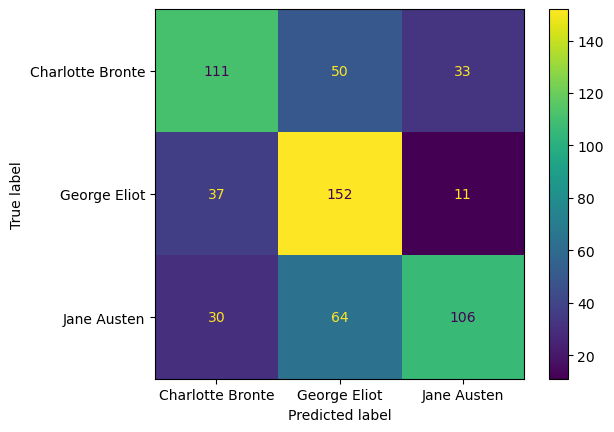

In [247]:
# Confusion matrix per la configurazione sum su NOUN, ADJ, VERB (sum)   
ConfusionMatrixDisplay.from_predictions(test_labels_2, test_pred_2)